In [1]:
import sys
sys.path.append('..')

from Agent.config import LLM, SMALL_LLM, SMART_LLM, EMBEDDING, CLIENT
from IPython.display import display, Image, Markdown

In [2]:
from langchain_chroma import Chroma


database = Chroma(
  collection_name= 'chroma-tax',
  persist_directory= '../db/by-article-upstage',
  embedding_function= EMBEDDING     
)

retriever = database.as_retriever(
    search_type= 'mmr',
    search_kwargs={
        'k': 4,
        'fetch_k': 10,
        'lambda_mult': 0.6
    }
)

In [3]:
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_community.utilities.semanticscholar import SemanticScholarAPIWrapper
from langchain_community.tools.tavily_search import TavilySearchResults


@tool       # 데코레이터 @tool로 감싸고
def add(num1: int, num2: int) -> int:     # 함수와 변수의 이름, typehint가 schema(구조)로서, JSON 형식으로 LLM에 전달됨
    '''
    정수 num1와 num2를 더합니다. 
    '''         # 이 부분의 description(프롬프트와 같음)도 마찬가지로 LLM에 전달됨
    return num1+num2

@tool
def multiply(num1: int, num2: int) -> int:
    '''
    정수 num1와 num2를 곱합니다. 
    '''
    return num1*num2

search_tool = TavilySearchResults()

@tool
def search(query: str) -> str:
    '''
    사용자의 질문에 알고 있는 지식만으로 답변하기 힘든 경우,
    주어진 query에 대해 tavily 검색을 수행하고, 요약된 결과를 반환합니다.
    '''
    # 1. 검색 수행
    results = search_tool.invoke(query)
    
    # 2. 요약 프롬프트
    prompt = ChatPromptTemplate.from_messages([
        ("system", "당신은 검색 결과를 요약하는 전문가입니다. 검색 결과를 바탕으로 사용자의 질문에 간결하고 정확하게 답변하세요."),
        ("human", "질문: {query}\n\n검색 결과:\n{results}\n\n위 검색 결과를 바탕으로 질문에 답변해주세요.")
    ])
    
    # 3. Chain 구성 (비용 절약을 위해 small_llm 사용)
    chain = prompt | SMALL_LLM | StrOutputParser()
    
    # 4. 요약 실행
    summary = chain.invoke({"query": query, "results": results})
    
    return summary


semantic_scholar_wrapper = SemanticScholarAPIWrapper(
    top_k_results=5,
    doc_content_chars_max=6000,  # 더 긴 초록
)

@tool
def search_semantic_scholar(query: str) -> str:
    '''
    Semantic Scholar에서 peer-reviewed 학술 논문을 검색합니다.
    인용 수(citation count)가 포함되어 논문 품질을 판단할 수 있습니다.
    
    Args:
        query: 검색어 (예: "LLM agent reasoning")
    '''
    return semantic_scholar_wrapper.run(query)

In [4]:
@tool
def search_income_tax_law(query: str) -> str:
    '''소득세 관련 법령 조문을 검색합니다.

    이럴 때 사용:
    - 과세표준 계산 근거가 필요할 때
    - 세율표, 공제 조건 등 법적 기준 확인
    - 특정 조문 번호로 검색 (예: "소득세법 55조")

    이럴 때 사용하지 마세요:
    - 단순 세금 계산 → calculate_tax 도구
    - 최신 세율/공제 한도 → web_search 도구

    반환: 관련 법령 조문 (최대 4개, 출처 포함)
    '''
    try:
        docs = retriever.invoke(query)
    except Exception as e:
        return f"검색 중 오류 발생: {str(e)}"
    
    if not docs:
        return "관련 법령을 찾지 못했습니다. 다른 키워드로 검색해주세요."
    
    # 중복 조문 제거
    seen = set()
    unique_docs = []
    for doc in docs:
        key = doc.metadata.get('article', doc.page_content[:50])
        if key not in seen:
            seen.add(key)
            unique_docs.append(doc)
    
    # 포맷팅
    results = []
    for doc in unique_docs[:4]:
        source = doc.metadata.get('source', '출처 미상')
        article = doc.metadata.get('article', '')
        results.append(f"[{source} {article}]\n{doc.page_content}")
    
    return "\n\n".join(results)

In [5]:
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply, search, search_semantic_scholar, search_income_tax_law]

small_llm_with_tools = SMALL_LLM.bind_tools(tool_list)
smart_llm_with_tools = SMALL_LLM.bind_tools(tool_list)

tool_node = ToolNode(tool_list)

In [6]:
from langgraph.graph import START, END
from langgraph.graph import MessagesState, StateGraph
from langchain_core.messages import RemoveMessage, SystemMessage



class AgentState(MessagesState):
    summary: str = None

message_count_to_keep = 12

def summarize_message(state: AgentState):
    message = state['messages'][:-message_count_to_keep]
    summary = state['summary']

    chat_text = "\n".join(
        f"{m.type}: {m.content}"
        for m in message
        if m.content
    )

    summary_prompt = f"""\
You are a conversation summarizer. Summarize the chat history below into a concise summary.

Rules:
- Preserve all specific names, numbers, dates, and key decisions
- Capture what the user requested and what actions were taken
- Note any tool calls and their results (e.g. emails sent, searches performed)
- Keep the summary under 200 words
- Write in the same language the user used

Chat history:
{chat_text}

Summary:"""
    if summary:
        summary_prompt = f"""\
You are a conversation summarizer. Update the existing summary by incorporating the new chat history below.

Rules:
- Merge new information into the existing summary, do not simply append
- Preserve all specific names, numbers, dates, and key decisions from both the existing summary and new history
- Remove outdated or superseded information (e.g. if a decision was changed)
- Capture what the user requested and what actions were taken
- Note any tool calls and their results
- Keep the updated summary under 300 words
- Write in the same language the user used

Existing summary:
{summary}

New chat history:
{chat_text
}

Updated summary:"""

    response = LLM.invoke(summary_prompt)
    return {'summary': response.content}

def delete_messages(state: AgentState):
    messages = state['messages']
    deleted_messages = [RemoveMessage(id=message.id) for message in messages[:-message_count_to_keep]]
    return {'messages': deleted_messages}


## agent 여기있어요
def agent(state: AgentState):
    summary = state['summary']
    messages = state['messages']
    if summary:
        messages = [SystemMessage(content=f'Here is the summary of the earlier conversation: {summary}')] + messages
    
    response = small_llm_with_tools.invoke(messages)
    return {'messages': [response]}

def should_continue(state: AgentState):
    messages = state['messages']
    if messages[-1].tool_calls:
        return 'human_review'
    if len(messages) > message_count_to_keep:
        return 'summarize_message'
    return END

## Human in the loop - 인간이 edge가 돼
Human in the loop에는 두가지 종류가 있다.
1. 사람이 conditional edge로서 기능
2. 사람이 Routing 또는 Editing edge로서 기능

In [7]:
from langgraph.types import interrupt, Command
from typing import Literal

def human_review(state: AgentState) -> Command[Literal['tools', 'agent']]:
    messages = state['messages']
    last_message = messages[-1]
    tool_call = last_message.tool_calls[-1]
    human_review = interrupt({
        'question': '이렇게 진행하면 되나요?',      # 사람에게 보여줄 질문
        'tool_call': tool_call                    # 사람이 검토할 tool call 정보
    })
    review_action = human_review['action']
    review_data = human_review.get('data', {})
    
    if review_action == 'approve':
        return Command(goto='tools')
    
    if review_action == 'update_args':
        updated_ai_message = {
            'id': last_message.id,
            'role': 'ai',
            'content': last_message.content,
            'tool_calls': [{
                'id': tool_call['id'],
                'name': tool_call['name'],
                'args': review_data        # 사람이 수정한 인자
            }],
        }
        return Command(goto='tools', update={'messages': [updated_ai_message]})
    
    if review_action == 'update_tool':
        updated_tool_message = {
            'tool_call_id': tool_call['id'],
            'name': tool_call['name'],
            'role': 'tool',            # ← ToolMessage를 만들고 있음
            'content': review_data     # ← 사람이 넣은 텍스트가 tool 결과인 척
        }
        return Command(goto='agent', update={'messages': [updated_tool_message]})

In [ ]:
graph_builder = StateGraph(AgentState)

graph_builder.add_node('agent', agent) 
graph_builder.add_node('tools', tool_node)
graph_builder.add_node('human_review', human_review)
graph_builder.add_node('summarize_message', summarize_message)
graph_builder.add_node('delete_messages', delete_messages)

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    should_continue,
    {
        'human_review': 'human_review',
        'summarize_message': 'summarize_message',
        END: END
    }
)


graph_builder.add_edge('tools', 'agent')
graph_builder.add_edge('summarize_message', 'delete_messages')
graph_builder.add_edge('delete_messages', END)

In [32]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

In [33]:
graph = graph_builder.compile(
    checkpointer=checkpointer
)

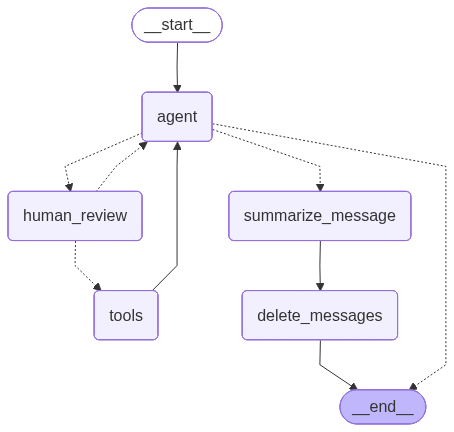

In [34]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [35]:
test_config = {
    'configurable': {
        'thread_id': 'test-thread-001'
    }
}

In [39]:
from langchain_core.messages import HumanMessage

query = '합자회사의 예시를 알려주세요'

for chunk in graph.stream(
    {'messages': [HumanMessage(query)], 'summary': ''}, config=test_config, stream_mode= 'values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

합자회사의 예시를 알려주세요
================================== Ai Message ==================================

[{'text': '합자회사의 구체적인 예시를 검색해드리겠습니다.', 'type': 'text'}, {'id': 'toolu_01P2uVVDVp8k6ywijREihKuP', 'input': {'query': '합자회사 예시 사례'}, 'name': 'search', 'type': 'tool_use'}]
Tool Calls:
  search (toolu_01P2uVVDVp8k6ywijREihKuP)
 Call ID: toolu_01P2uVVDVp8k6ywijREihKuP
  Args:
    query: 합자회사 예시 사례


In [ ]:
graph.get_state(test_config).next

()

In [41]:
for chunk in graph.stream(
    Command(resume={"action": "approve"}),
    test_config,
    stream_mode="updates",
):
    print(f'chunk == {chunk}')

chunk == {'human_review': None}
chunk == {'tools': {'messages': [ToolMessage(content="# 합자회사 형태의 한국 사모펀드 기업 사례\n\n## 사모펀드의 합자회사 구조\n\n한국의 사모펀드(PEF, Private Equity Fund)는 **상법상 합자회사 형태**를 취하고 있습니다.\n\n### 조직 구성\n- **무한책임사원(GP, General Partner)**: 펀드 운용회사로서 투자자금 조달 및 투자 집행 담당\n- **유한책임사원(LP, Limited Partner)**: 투자자금만 위탁하며 투자금액 범위 내에서만 책임\n\n## 주요 한국 기업 투자 사례\n\n검색 결과에 따르면 주요 사모펀드들의 포트폴리오 기업들은 다음과 같습니다:\n\n### VIG파트너스\n- Eastar Jet Co., Ltd. (운송, 2023년)\n- T'way Air Co., Ltd. (운송, 2021년)\n- Megazone Cloud Corporation (S/W, 2020년)\n- Bonchon International Inc. (레저·엔터, 2018년)\n\n### JKL파트너스\n- Sama Aluminium Co Ltd (산업재, 2023년)\n- DSEV (전기전자, 2022년)\n- LS MnM (산업재, 2022년)\n\n## 투자 목적 및 방식\n\n사모펀드는 일반적으로 **5~6년 내외 기간 동안 투자를 유지**한 후, 기업 가치 상승 시 전략적 매각, 재매각, 또는 IPO를 통해 투자금을 회수합니다.", name='search', id='53418a97-df9a-4a7a-89f6-db359352c292', tool_call_id='toolu_011U6MM6KXND9c1kypaWx65M')]}}
chunk == {'agent': {'messages': [AIMessage(content="## 합자회사의 예시\n\n### 📊 **사모펀드(PEF, Private Equity Fund)*

In [40]:
for chunk in graph.stream(
    Command(resume={"action": "update_tool", "data": "query를 더 구체적으로 작성해주세요"}),
    test_config,
    stream_mode="updates",
):
    print(f'chunk == {chunk}')

chunk == {'human_review': {'messages': [{'tool_call_id': 'toolu_01P2uVVDVp8k6ywijREihKuP', 'name': 'search', 'role': 'tool', 'content': 'query를 더 구체적으로 작성해주세요'}]}}
chunk == {'agent': {'messages': [AIMessage(content=[{'text': '다시 검색해보겠습니다.', 'type': 'text'}, {'id': 'toolu_011U6MM6KXND9c1kypaWx65M', 'input': {'query': '합자회사 한국 기업 사례 사모펀드'}, 'name': 'search', 'type': 'tool_use'}], additional_kwargs={}, response_metadata={'id': 'msg_017meXk714qp32YQvRQA6ZmM', 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'input_tokens': 4144, 'output_tokens': 83, 'server_tool_use': None, 'service_tier': 'standard', 'inference_geo': 'not_available'}, 'model_name': 'claude-haiku-4-5-20251001'}, id='lc_run--019c4626-ab34-7a30-aed1-8bb969c32c18-0', tool_calls=[{'name': 'search', 'args': {'query': '합자회사 한국 기업 사례 사모

In [ ]:
# 난 이 방법 별로.. update tools에서 args 수정 요구하면 그대로 해줌

for chunk in graph.stream(
    Command(resume={"action": "update_args", "data": {'query': '금융위의 최근 조치에 대해 자세히 조사해줘'}}),
    test_config,
    stream_mode="updates",
):
    print(f'chunk == {chunk}')

In [42]:
graph.get_state(test_config).values['messages']

[HumanMessage(content='회사의 종류에는 어떤 것들이 있나요?', additional_kwargs={}, response_metadata={}, id='e3c5112d-7eff-4d5d-a7e1-573aeb4f8092'),
 AIMessage(content=[{'text': '회사의 종류에 대해 검색해드리겠습니다.', 'type': 'text'}, {'id': 'toolu_017MvHa26wPZbGsfV5Yi5Koj', 'input': {'query': '회사의 종류 분류'}, 'name': 'search', 'type': 'tool_use'}], additional_kwargs={}, response_metadata={'id': 'msg_01DuAkXj8dmyMKzEz6JCyeeS', 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'input_tokens': 1892, 'output_tokens': 83, 'server_tool_use': None, 'service_tier': 'standard', 'inference_geo': 'not_available'}, 'model_name': 'claude-haiku-4-5-20251001'}, id='lc_run--019c4624-18cd-7f01-aafc-9b44cdfea85a-0', tool_calls=[{'name': 'search', 'args': {'query': '회사의 종류 분류'}, 'id': 'toolu_017MvHa26wPZbGsfV5Yi5Koj', 'type': 'tool_call'}], in